## IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler



## DEFINITION OF VARIABLES

In [2]:
SOURCE_POLYMER_FILE = 'all_spectra.csv'
SOURCE_MICROPLASTIC_FILE = 'ambient_spectra.csv'
NORMAL_POLYMER = 'Polypropylene'

## Affine Coupling Layer

In [3]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.split_dim = dim // 2

        self.scale_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim)),
            nn.Tanh()
        )

        self.shift_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(self.split_dim, hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim,hidden_dim)),
            nn.ReLU(),
            nn.utils.spectral_norm(nn.Linear(hidden_dim, dim - self.split_dim))
        )

    def forward(self, x):
        x1,x2 = x[:,:self.split_dim], x[:,self.split_dim:]

        s = self.scale_net(x1)
        s = s * 0.3
        t = self.shift_net(x1)

        y1 = x1
        y2 = x2 * torch.exp(s) + t

        log_det = s.sum(dim = 1)

        return torch.cat([y1, y2], dim=1), log_det
    
    def inverse(self, y):
        y1, y2 = y[:, :self.split_dim], y[:, self.split_dim:]

        s = self.scale_net(y1)
        s = s * 0.3
        t = self.shift_net(y1)

        x1 = y1
        x2 = (y2 - t) * torch.exp(-s)

        return torch.cat([x1, x2], dim=1)

In [4]:
class StandardGaussian:
    def __init__(self, dim):
        self.dim = dim
        self.distribution = torch.distributions.MultivariateNormal(
            torch.zeros(dim),
            torch.eye(dim)
        )

    def log_prob(self, z):
        return self.distribution.log_prob(z)
    
    def sample(self, n_samples):
        return self.distribution.sample((n_samples,))


In [5]:
class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.register_buffer('permutation', torch.randperm(dim))
        self.register_buffer('inverse_permutation', torch.argsort(self.permutation))

    def forward(self, x):
        return x[:, self.permutation], torch.zeros(x.shape[0], device=x.device)
    
    def inverse(self, y):
        return y[:,self.inverse_permutation]
    

In [6]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, n_layers = 4, hidden_dim = 64):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(AffineCouplingLayer(dim, hidden_dim))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):

        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        log_prob_z = self.base_dist.log_prob(z)
        log_prob_x = log_prob_z + log_det_sum

        return log_prob_x
    
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x
    
    def sample(self, n_samples):
        z = self.base_dist.sample(n_samples)
        x = self.inverse(z)
        return x


In [7]:
def train_flow(model, data, n_epochs = 100, batch_size = 32, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    n_batches = len(data) // batch_size
    losses = []

    for epoch in tqdm(range(n_epochs)):
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]

        epoch_loss = 0

        for i in range(n_batches):
            batch = data_shuffled[i*batch_size:(i+1)*batch_size]
            
            optimizer.zero_grad()

            log_prob = model(batch)
            loss = -log_prob.mean()

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

    return losses

## Training

In [8]:
# Load data
df_train = pd.read_csv(SOURCE_POLYMER_FILE, index_col=False)
df_test = pd.read_csv(SOURCE_MICROPLASTIC_FILE, index_col=False)

print(f"Training data (normal polymers): {df_train.shape[0]} samples")
print(f"Test data (abnormal microplastics): {df_test.shape[0]} samples")

Training data (normal polymers): 1215 samples
Test data (abnormal microplastics): 55 samples


In [ ]:
# Prepare training data (normal)
normal_data = df_train.drop('polymer', axis=1).values

# TRY: Train WITHOUT scaling to preserve spectral differences
# This keeps the actual intensity differences that make microplastics anomalous!
scaler = None  # No scaling
normal_scaled = normal_data.astype(np.float32)
train_tensor = torch.FloatTensor(normal_scaled)

# ALTERNATIVE: Use RobustScaler if values are too extreme
# scaler = RobustScaler()
# normal_scaled = scaler.fit_transform(normal_data)
# train_tensor = torch.FloatTensor(normal_scaled)

# Initialize and train model
n_features = train_tensor.shape[1]
model = NormalizingFlow(dim = n_features, n_layers = 6, hidden_dim = 256)

print(f"\nTraining Normalizing Flow model (NO SCALING - preserves spectral differences)...")
print(f"Feature 0 range: [{normal_data[:, 0].min():.2f}, {normal_data[:, 0].max():.2f}]")
losses = train_flow(model, train_tensor, n_epochs = 100, batch_size = 32, lr = 1e-4)



Training Normalizing Flow model...


 10%|█         | 10/100 [00:25<03:43,  2.48s/it]

Epoch 10/100, Loss: 390.9232


 20%|██        | 20/100 [01:25<09:08,  6.85s/it]

Epoch 20/100, Loss: 323.6680


...

Epoch 80/100, Loss: 179.7373


 90%|█████████ | 90/100 [05:49<00:29,  2.96s/it]

Epoch 90/100, Loss: 167.3670


100%|██████████| 100/100 [06:19<00:00,  3.80s/it]

Epoch 100/100, Loss: 156.3043


In [ ]:
# Plot training loss to diagnose convergence
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, color='blue')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss change (first to last epoch): {losses[0] - losses[-1]:.4f}")
if losses[-1] > losses[-10]:
    print("⚠️  WARNING: Loss is increasing in recent epochs - model may not be converging well")
else:
    print("✓ Loss is decreasing - training appears stable")


ANOMALY DETECTION: Training Data Statistics
Training samples: 1215
Mean log probability: -155.7675
Std log probability: 95.9054
Threshold (mean - 2*std): -347.5782
Threshold (anomaly score): 347.5782

CLASSIFYING TEST DATA (Microplastics)

Total test samples: 55
Classified as ANOMALY: 25 (45.5%)
Classified as NORMAL: 30 (54.5%)

PER-SAMPLE RESULTS (first 20 samples)

 Sample_Index  Log_Probability  Anomaly_Score  Is_Anomaly Classification Polymer_Type
            0      -436.526123     436.526123           1        ANOMALY          AMB
            1      -209.042328     209.042328           0         NORMAL          AMB
            2      -185.093109     185.093109           0         NORMAL          AMB
            3      -239.607086     239.607086           0         NORMAL          AMB
            4      -917.765259     917.765259           1        ANOMALY          AMB
            5      -385.748962     385.748962           1        ANOMALY          AMB
            6      -316.5986

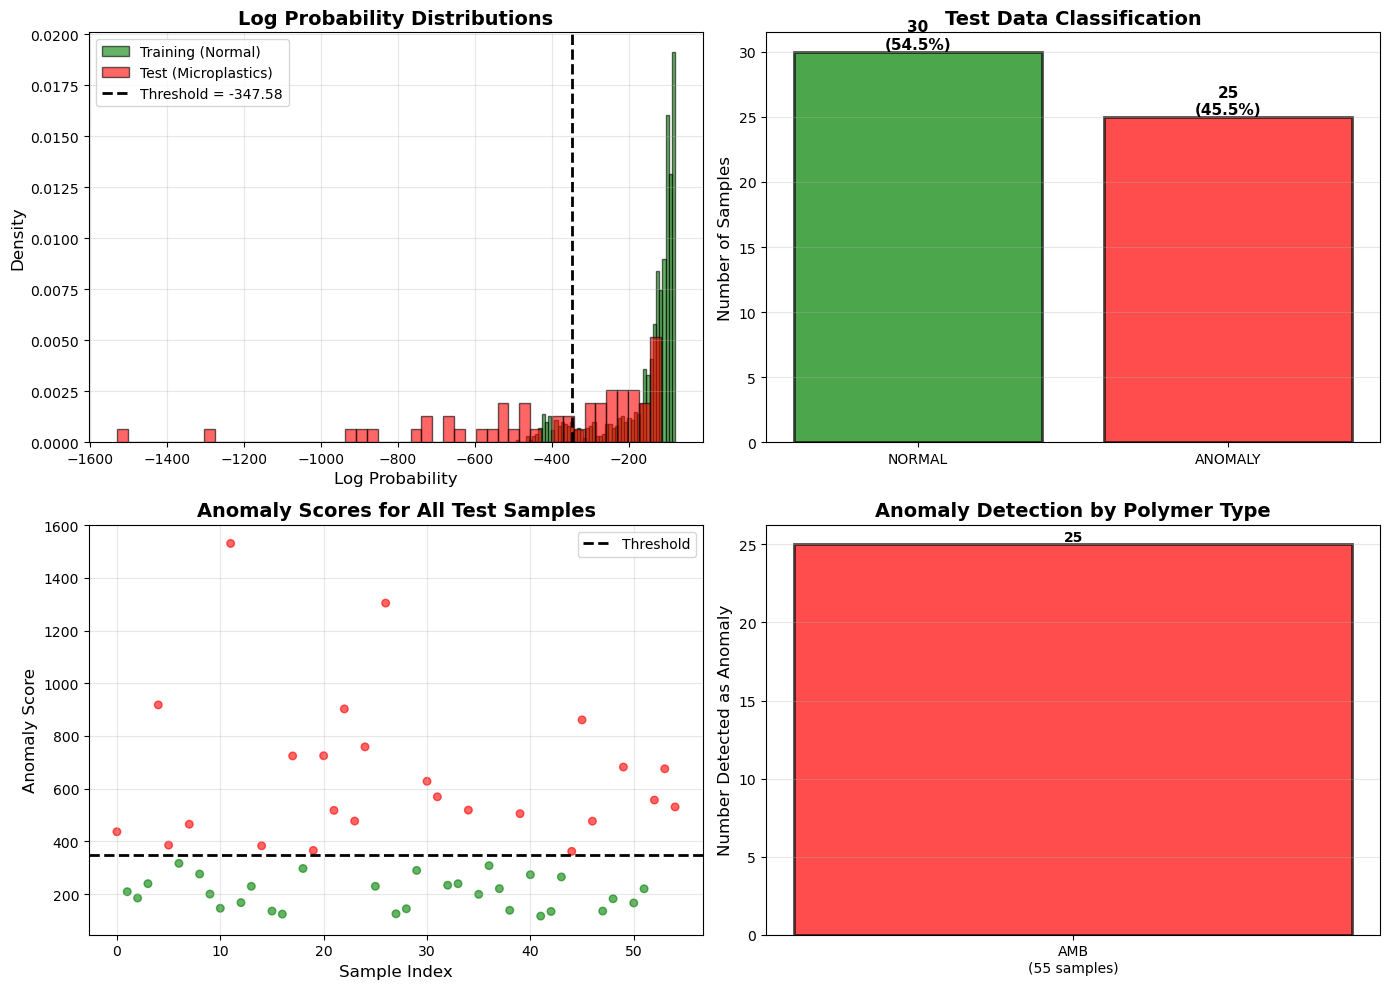


Results saved to: anomaly_detection_results.csv


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# EVALUATION: Classify test data (microplastics) as anomaly or normal
# ============================================================================

model.eval()

# Step 1: Score TRAINING data to compute threshold
with torch.no_grad():
    train_log_probs = model(train_tensor).cpu().numpy()

# Compute threshold from training data statistics
# (lower log probability = more anomalous)
train_mean = train_log_probs.mean()
train_std = train_log_probs.std()
threshold_log_prob = train_mean - 2 * train_std  # 2-sigma threshold
threshold_anomaly_score = -threshold_log_prob

print(f"{'='*70}")
print(f"ANOMALY DETECTION: Training Data Statistics")
print(f"{'='*70}")
print(f"Training samples: {len(train_log_probs)}")
print(f"Mean log probability: {train_mean:.4f}")
print(f"Std log probability: {train_std:.4f}")
print(f"Threshold (mean - 2*std): {threshold_log_prob:.4f}")
print(f"Threshold (anomaly score): {threshold_anomaly_score:.4f}")

# Step 2: Score TEST data (microplastics)
print(f"\n{'='*70}")
print(f"CLASSIFYING TEST DATA (Microplastics)")
print(f"{'='*70}\n")

with torch.no_grad():
    test_data = df_test.drop('polymer', axis=1).values
    if scaler is not None:
        test_scaled = scaler.transform(test_data)
    else:
        test_scaled = test_data.astype(np.float32)
    test_tensor = torch.FloatTensor(test_scaled)
    test_log_probs = model(test_tensor).cpu().numpy()

test_anomaly_scores = -test_log_probs
test_predictions = (test_anomaly_scores >= threshold_anomaly_score).astype(int)

# Step 3: Create results dataframe
results_df = pd.DataFrame({
    'Sample_Index': range(len(test_log_probs)),
    'Log_Probability': test_log_probs.flatten(),
    'Anomaly_Score': test_anomaly_scores.flatten(),
    'Is_Anomaly': test_predictions,
    'Classification': ['ANOMALY' if p == 1 else 'NORMAL' for p in test_predictions]
})

# Add polymer type if available
if 'polymer' in df_test.columns:
    results_df['Polymer_Type'] = df_test['polymer'].values

# Display summary
anomaly_count = test_predictions.sum()
normal_count = len(test_predictions) - anomaly_count

print(f"Total test samples: {len(test_predictions)}")
print(f"Classified as ANOMALY: {anomaly_count} ({100*anomaly_count/len(test_predictions):.1f}%)")
print(f"Classified as NORMAL: {normal_count} ({100*normal_count/len(test_predictions):.1f}%)")

# Display per-sample results
print(f"\n{'='*70}")
print(f"PER-SAMPLE RESULTS (first 20 samples)")
print(f"{'='*70}\n")
print(results_df.head(20).to_string(index=False))

if len(results_df) > 20:
    print(f"\n... and {len(results_df) - 20} more samples")

# Step 4: Per-polymer breakdown (if available)
if 'polymer' in df_test.columns:
    print(f"\n{'='*70}")
    print(f"RESULTS BY POLYMER TYPE")
    print(f"{'='*70}")
    
    for polymer in df_test['polymer'].unique():
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        
        anomaly_detected = polymer_results['Is_Anomaly'].sum()
        total = len(polymer_results)
        pct = 100 * anomaly_detected / total
        avg_anomaly_score = polymer_results['Anomaly_Score'].mean()
        
        print(f"\n{polymer}:")
        print(f"  Total samples: {total}")
        print(f"  Detected as ANOMALY: {anomaly_detected}/{total} ({pct:.1f}%)")
        print(f"  Avg anomaly score: {avg_anomaly_score:.4f}")

# Step 5: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of anomaly scores for train and test data
ax = axes[0, 0]
ax.hist(train_log_probs, bins=50, alpha=0.6, label='Training (Normal)', 
        color='green', edgecolor='black', density=True)
ax.hist(test_log_probs, bins=50, alpha=0.6, label='Test (Microplastics)', 
        color='red', edgecolor='black', density=True)
ax.axvline(threshold_log_prob, color='black', linestyle='--', linewidth=2, 
          label=f'Threshold = {threshold_log_prob:.2f}')
ax.set_xlabel('Log Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Log Probability Distributions', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Classification results bar chart
ax = axes[0, 1]
labels = ['NORMAL', 'ANOMALY']
counts = [normal_count, anomaly_count]
colors = ['green', 'red']
bars = ax.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Test Data Classification', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}\n({100*count/len(test_predictions):.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: Anomaly scores scatter plot
ax = axes[1, 0]
colors_scatter = ['red' if p == 1 else 'green' for p in test_predictions]
ax.scatter(range(len(test_anomaly_scores)), test_anomaly_scores, c=colors_scatter, alpha=0.6, s=30)
ax.axhline(threshold_anomaly_score, color='black', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Anomaly Score', fontsize=12)
ax.set_title('Anomaly Scores for All Test Samples', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Distribution by polymer type (if available)
if 'polymer' in df_test.columns:
    ax = axes[1, 1]
    polymer_types = results_df['Polymer_Type'].unique()
    anomaly_by_polymer = []
    labels_by_polymer = []
    
    for polymer in polymer_types:
        polymer_mask = results_df['Polymer_Type'] == polymer
        anomaly_count_polymer = results_df[polymer_mask]['Is_Anomaly'].sum()
        anomaly_by_polymer.append(anomaly_count_polymer)
        labels_by_polymer.append(f"{polymer}\n({results_df[polymer_mask].shape[0]} samples)")
    
    bars = ax.bar(range(len(polymer_types)), anomaly_by_polymer, color='red', alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xticks(range(len(polymer_types)))
    ax.set_xticklabels(labels_by_polymer)
    ax.set_ylabel('Number Detected as Anomaly', fontsize=12)
    ax.set_title('Anomaly Detection by Polymer Type', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, count in zip(bars, anomaly_by_polymer):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(count)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Step 6: Save results to CSV
output_filename = 'anomaly_detection_results.csv'
results_df.to_csv(output_filename, index=False)
print(f"\n{'='*70}")
print(f"Results saved to: {output_filename}")
print(f"{'='*70}")

### Improvements
restrict to a limited number of polymers for training (using a subset)
1. address the issue that they come from different distributions
2. conditional normalizing 
3. selected number of polymers